In [ ]:
import pandas as pd

In [ ]:
import zipfile

# Unzip the archive to extract the CSV file
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv('SOCR-HeightWeight.csv')

In [ ]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [ ]:
x=df[["Height(Inches)"]]

In [ ]:
y=df[["Weight(Pounds)"]]

In [ ]:
df.isnull().any()

,0
Index,False
Height(Inches),False
Weight(Pounds),False


In [ ]:
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


In [ ]:
!pip install scikit-learn
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('SOCR-HeightWeight.csv')

In [ ]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


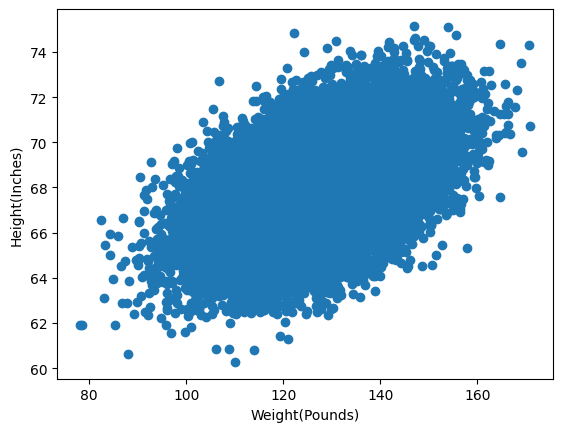

In [ ]:
plt.scatter(df["Weight(Pounds)"],df["Height(Inches)"])
plt.xlabel("Weight(Pounds)")
plt.ylabel("Height(Inches)")
plt.show()

In [ ]:
df.corr()

,Index,Height(Inches),Weight(Pounds)
Index,1.000000,0.009626,-0.007257
Height(Inches),0.009626,1.000000,0.502859
Weight(Pounds),-0.007257,0.502859,1.000000


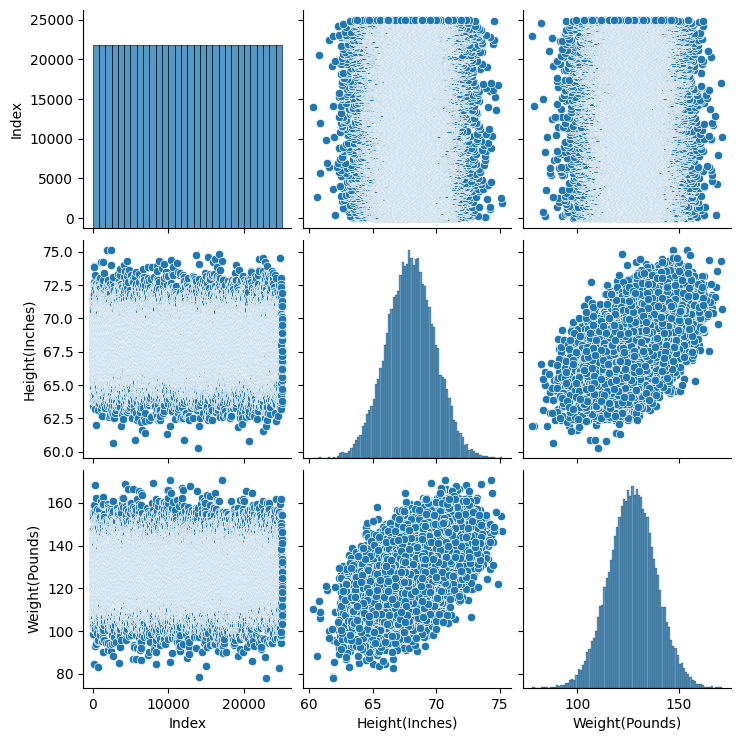

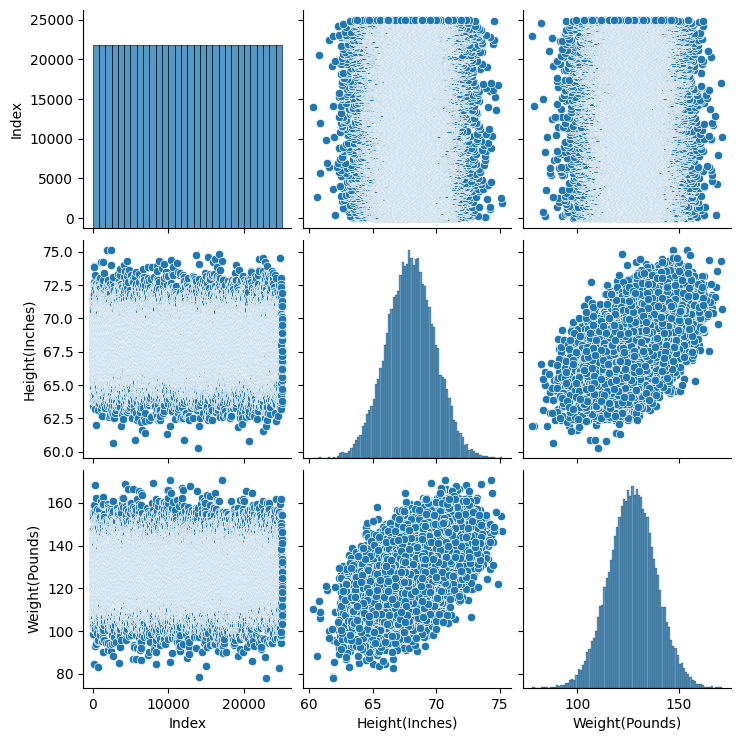

In [ ]:
sns.pairplot(df)
plt.show()

sns.pairplot(df)
plt.show()


In [ ]:
#Seperating X and y
# X->independent feature must be in 2D
# y->output feature must be in 1D

X=df[['Weight(Pounds)']]
y=df['Height(Inches)']

In [ ]:
X.shape


(25000, 1)

In [ ]:
y.shape

(25000,)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42  # Changed from 0.25 to 42 as random_state should be an integer
)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
Scaler=StandardScaler()

In [ ]:
X_train=Scaler.fit_transform(X_train)

In [ ]:
X_test=Scaler.transform(X_test)

In [ ]:
X_test

array([[ 0.62053543],
       [-1.29869704],
       [ 0.76685832],
       ...,
       [ 0.73940988],
       [-1.16790419],
       [ 0.00246396]])

In [ ]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)
print("slope :",regression.coef_)
print("Intercept :",regression.intercept_)

slope : [0.94883892]
Intercept : 67.9938252704


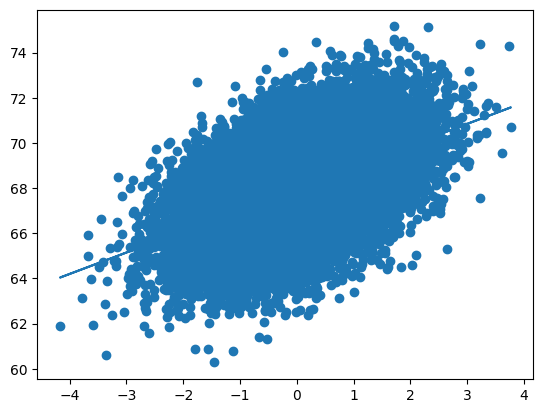

In [ ]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [ ]:
y_pred=regression.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


2.7333807993730996
1.3166150322297803
1.6532939240719116


In [ ]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred)
print(score)

0.2592643941428425


In [ ]:
#Adjusted r2 squared

1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)


0.25914583850810224

In [ ]:
#OLS linear regression

import statsmodels.api as sm

model=sm.OLS(y_train,X_train).fit()

prediction=model.predict(X_test)
print(prediction)

[ 0.58878817 -1.2322543   0.72762503 ...  0.70158088 -1.10815295
  0.0023379 ]


In [ ]:
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:         Height(Inches)   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              3.649
Date:                Fri, 29 May 2026   Prob (F-statistic):                      0.0561
Time:                        06:54:35   Log-Likelihood:                     -1.0572e+05
No. Observations:               18750   AIC:                                  2.115e+05
Df Residuals:                   18749   BIC:                                  2.115e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
 #predicting new data

regression.predict(Scaler.transform([[75]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([63.74539415])

In [ ]:
# Installing the pyspark

!pip install pyspark --quiet


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Creating the spark session
spark = SparkSession.builder \
      .appName('Day4_big_data_sales')\
      .getOrCreate()

In [ ]:
# Load the dataset
sales_df = spark.read.csv("/content/large_sales_data.csv", header=True, inferSchema=True)

print("PySpark DataFrame loaded successfully!")

PySpark DataFrame loaded successfully!


In [ ]:
# Create a dummy large_sales_data.csv file for demonstration
import pandas as pd
import numpy as np

np.random.seed(42)
data_size = 1000 # Small size for quick demo, but conceptually represents 'large'

dummy_data = {
    'TransactionID': np.arange(1, data_size + 1),
    'ProductID': np.random.randint(101, 110, data_size),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Home Goods', 'Books'], data_size),
    'Quantity': np.random.randint(1, 10, data_size),
    'Price': np.round(np.random.uniform(10.0, 500.0, data_size), 2),
    'CustomerID': np.random.randint(1001, 1050, data_size),
    'TransactionDate': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, data_size), unit='D'),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], data_size)
}

dummy_df_pandas = pd.DataFrame(dummy_data)
dummy_df_pandas.to_csv('large_sales_data.csv', index=False)

print("Dummy 'large_sales_data.csv' created successfully!")

Dummy 'large_sales_data.csv' created successfully!


In [ ]:
# Load the dataset (re-attempt after creating dummy file)
sales_df = spark.read.csv("large_sales_data.csv", header=True, inferSchema=True)

print("PySpark DataFrame loaded successfully!")



In [1]:
# Create a dummy large_sales_data.csv file for demonstration
import pandas as pd
import numpy as np

np.random.seed(42)
data_size = 1000 # Small size for quick demo, but conceptually represents 'large'

dummy_data = {
    'TransactionID': np.arange(1, data_size + 1),
    'ProductID': np.random.randint(101, 110, data_size),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Home Goods', 'Books'], data_size),
    'Quantity': np.random.randint(1, 10, data_size),
    'Price': np.round(np.random.uniform(10.0, 500.0, data_size), 2),
    'CustomerID': np.random.randint(1001, 1050, data_size),
    'TransactionDate': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, data_size), unit='D'),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], data_size)
}

dummy_df_pandas = pd.DataFrame(dummy_data)
dummy_df_pandas.to_csv('large_sales_data.csv', index=False)

print("Dummy 'large_sales_data.csv' created successfully!")

Dummy 'large_sales_data.csv' created successfully!


In [1]:
# Load the dataset (re-attempt after creating dummy file)
sales_df = spark.read.csv("large_sales_data.csv", header=True, inferSchema=True)

print("PySpark DataFrame loaded successfully!")



In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("SalesData").getOrCreate()

sales_df = spark.read.csv("large_sales_data.csv", header=True, inferSchema=True)

sales_df.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [5]:
# Show the first 5 rows of the DataFrame
sales_df.show(5)

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

In [6]:
# Get descriptive statistics
sales_df.describe().show()

+-------+------------------+-------------+----------+-----------+-----------------+------------------+------------------+---------+------+-----------+----------------+------------+
|summary|          order_id|customer_name|   product|   category|         quantity|        unit_price|           revenue|     city|region|  sales_rep|  payment_method|order_status|
+-------+------------------+-------------+----------+-----------+-----------------+------------------+------------------+---------+------+-----------+----------------+------------+
|  count|              5000|         5000|      5000|       5000|             5000|              5000|              5000|     5000|  5000|       5000|            5000|        5000|
|   mean|            3500.5|         NULL|      NULL|       NULL|           7.9536|          12496.86|          99169.52|     NULL|  NULL|       NULL|            NULL|        NULL|
| stddev|1443.5200033252052|         NULL|      NULL|       NULL|4.275313169878912|14857.384309

In [7]:
# Count the number of rows
print(f"Total number of records: {sales_df.count()}")

Total number of records: 5000


In [10]:
from pyspark.sql.functions import col

# Filter sales data for 'Electronics' category and Quantity > 5
electronics_sales_df = sales_df.filter((col("category") == "Electronics") & (col("quantity") > 5))

print("Filtered sales (Electronics, Quantity > 5):")
electronics_sales_df.show(5)

Filtered sales (Electronics, Quantity > 5):
+--------+-------------+----------+-----------+--------+----------+-------+----------+-------+------+-----------+--------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|   city|region|  sales_rep|payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+-------+------+-----------+--------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21| Mumbai|  West|Meera Patel|           UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|  Delhi| North|Anil Sharma|   Credit Card|     Shipped|
|    1008|  Priya Patel|    Laptop|Electronics|      13|     45000| 585000|2023-05-29|Chennai| South|Meera Patel|   Credit Card|   Cancelled|
|    1009|   Amit Verma|Headphones|Electronics|      11|      3500|  38500|2023-07-06| Jaipur| North| Pr

In [13]:
# Select specific columns: ProductID, Category, Quantity, Price
selected_columns_df = sales_df.select("product", "category", "quantity", "unit_price")

print("Selected columns:")
selected_columns_df.show(5)

Selected columns:
+----------+-----------+--------+----------+
|   product|   category|quantity|unit_price|
+----------+-----------+--------+----------+
|   Monitor|Electronics|      12|     22000|
|   Printer|Electronics|      10|     12000|
|     Mouse|Accessories|      10|       800|
|    Tablet|Electronics|       5|     32000|
|Headphones|Electronics|       4|      3500|
+----------+-----------+--------+----------+
only showing top 5 rows


In [18]:
# Calculate total sales quantity and average price per category
# Explicitly cast 'quantity' and 'unit_price' to numeric types to handle potential type inference issues.
aggregated_sales_df = sales_df.groupBy("category").agg(
    F.sum(F.col("quantity").cast("integer")).alias("TotalQuantitySold"),
    F.avg(F.col("unit_price").cast("double")).alias("AveragePrice")
)

print("Aggregated sales by Category:")
aggregated_sales_df.show()

Aggregated sales by Category:
+-----------+-----------------+------------------+
|   category|TotalQuantitySold|      AveragePrice|
+-----------+-----------------+------------------+
|Electronics|            23222| 20260.83276912661|
|Accessories|            16546|1287.2922776148582|
+-----------+-----------------+------------------+



In [20]:
# Add a new column 'TotalPrice' (Quantity * Price)
from pyspark.sql.functions import col

sales_with_total_price_df = sales_df.withColumn(
    "TotalPrice", col("quantity") * col("unit_price")
)

print("DataFrame with 'TotalPrice' column:")
sales_with_total_price_df.show(5)

DataFrame with 'TotalPrice' column:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+----------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|TotalPrice|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+----------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|    264000|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|    120000|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|      8000|
|    1004|   Suresh Ra

In [22]:
# Load the dataset into a Pandas DataFrame
pandas_sales_df = pd.read_csv("/content/large_sales_data.csv")

print("Pandas DataFrame loaded successfully!")
print("Pandas DataFrame head:")
print(pandas_sales_df.head())

Pandas DataFrame loaded successfully!
Pandas DataFrame head:
   order_id customer_name     product     category  quantity  unit_price  \
0      1001   Sneha Reddy     Monitor  Electronics        12       22000   
1      1002  Ramesh Kumar     Printer  Electronics        10       12000   
2      1003  Rahul Mishra       Mouse  Accessories        10         800   
3      1004    Suresh Rao      Tablet  Electronics         5       32000   
4      1005   Priya Patel  Headphones  Electronics         4        3500   

   revenue  order_date       city region    sales_rep    payment_method  \
0   264000  2023-05-21     Mumbai   West  Meera Patel               UPI   
1   120000  2023-08-05      Delhi  North  Anil Sharma       Credit Card   
2     8000  2023-01-14  Ahmedabad   West  Meera Patel  Cash on Delivery   
3   160000  2023-01-04      Surat   West   Ravi Kumar  Cash on Delivery   
4    14000  2023-06-22  Bangalore  South   Sunita Rao  Cash on Delivery   

  order_status  
0    Delivered

In [24]:
# Pandas equivalent for filtering
pandas_electronics_sales_df = pandas_sales_df[
    (pandas_sales_df["category"] == "Electronics") &
    (pandas_sales_df["quantity"] > 5)
]

print("Filtered sales (Pandas - Electronics, Quantity > 5):")
print(pandas_electronics_sales_df.head())

Filtered sales (Pandas - Electronics, Quantity > 5):
   order_id customer_name     product     category  quantity  unit_price  \
0      1001   Sneha Reddy     Monitor  Electronics        12       22000   
1      1002  Ramesh Kumar     Printer  Electronics        10       12000   
7      1008   Priya Patel      Laptop  Electronics        13       45000   
8      1009    Amit Verma  Headphones  Electronics        11        3500   
9      1010    Amit Verma  Headphones  Electronics        10        3500   

   revenue  order_date     city region    sales_rep payment_method  \
0   264000  2023-05-21   Mumbai   West  Meera Patel            UPI   
1   120000  2023-08-05    Delhi  North  Anil Sharma    Credit Card   
7   585000  2023-05-29  Chennai  South  Meera Patel    Credit Card   
8    38500  2023-07-06   Jaipur  North   Priya Nair    Net Banking   
9    35000  2023-11-22    Delhi  North  Meera Patel            UPI   

  order_status  
0    Delivered  
1      Shipped  
7    Cancelled  
8

In [26]:
# Pandas equivalent for selecting columns
pandas_selected_columns_df = pandas_sales_df[["product", "category", "quantity", "unit_price"]]

print("Selected columns (Pandas):")
print(pandas_selected_columns_df.head())

Selected columns (Pandas):
      product     category  quantity  unit_price
0     Monitor  Electronics        12       22000
1     Printer  Electronics        10       12000
2       Mouse  Accessories        10         800
3      Tablet  Electronics         5       32000
4  Headphones  Electronics         4        3500


In [28]:
# Pandas equivalent for grouping and aggregating
pandas_aggregated_sales_df = pandas_sales_df.groupby("category").agg(
    TotalQuantitySold=('quantity', 'sum'),
    AveragePrice=('unit_price', 'mean')
).reset_index()

print("Aggregated sales by Category (Pandas):")
print(pandas_aggregated_sales_df)

Aggregated sales by Category (Pandas):
      category  TotalQuantitySold  AveragePrice
0  Accessories              16546   1287.292278
1  Electronics              23222  20260.832769
